# <center style='color:green'>Heart Attack | Analysis & Prediction</center>


## <span style='color:green'> Heart Attack Dataset</span>

- **Age**: Age of the person <span style='color:orange'>(1-100 years old)</span>
- **Sex**: Gender of the person <span style='color:orange'>( 0=female , 1=male )</span>
- **CP**: Chest pain type <span style='color:orange'>(0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic)</span>
- **TRTBPS**: Resting blood pressure <span style='color:orange'>(in mm Hg)</span>
- **Chol**: Cholesterol level <span style='color:orange'>(mg/dl) (1 = true; 0 = false)</span>
- **FBS**: Fasting blood sugar > 120 mg/dl <span style='color:orange'>(1 = true; 0 = false)</span>
- **Restecg**: Resting electrocardiographic results <span style='color:orange'>(0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy)</span>
- **Thalachh**: Maximum heart rate achieved 
- **Exng**: Exercise-induced angina <span style='color:orange'>(1 = yes; 0 = no)</span> 
- **Oldpeak**: Previous peak <span style='color:orange'>(measured in depression units)</span>
- **SLP**: Slope of the peak exercise segment <span style='color:orange'>(0 = upsloping, 1 = flat, 2 = downsloping)</span>
- **CAA**: Number of major vessels <span style='color:orange'>(0-3)</span> 
- **Thall**: Thalassemia rate 
- **Output**: Target variable indicating heart attack risk <span style='color:orange'>(0 = no heart attack, 1 = heart attack)</span>

## <span style='color:green'> Importing Libraries</span>

In [4]:
# General libraries
import warnings
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Plotting libraries
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

# Machine learning libraries
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# XGBoost library
from xgboost import XGBClassifier
import xgboost as xgb  # This ensures compatibility with both approaches

# Imbalanced learning library
from imblearn.over_sampling import SMOTE

# Suppress warnings
warnings.filterwarnings('ignore')

# Correlation graph
import seaborn as sns
import matplotlib.pyplot as plt

# Learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

## <span style='color:green'> Loading & Exploring Dataset</span>

In [6]:
# loading dataset and show the first 5 data of the dataset
df = pd.read_csv('C:/Users/IDK/Downloads/heartDataSet.csv')
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
# shape (row and column)
df.shape

(303, 14)

In [8]:
# identify duplicate data
df.duplicated().sum()

1

## <span style='color:green'> Exploratory Data Analysis (EDA)</span>

In [10]:
# Separating categorical and continuous features
categorical_features = []
continuous_features = []
target_feature = ["output"]

for i in df.columns[:-1]:
    if len(df[i].unique())<10:
        categorical_features.append(i)
    else:
        continuous_features.append(i)
        
print("The categorial features are : ", categorical_features)
print("The continuous features are : ", continuous_features)
print("The target variable is :  ", target_feature)

The categorial features are :  ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall']
The continuous features are :  ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
The target variable is :   ['output']


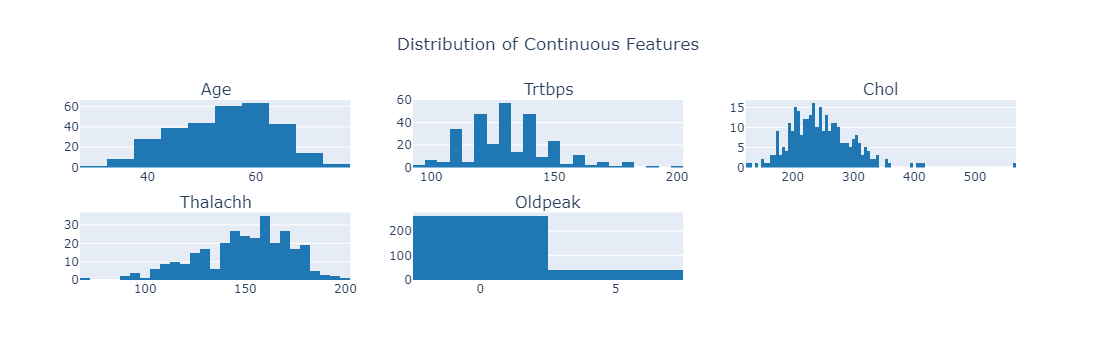

In [11]:
# Plotting Continous Feature Distributions
fig = make_subplots(rows=2, cols=3, subplot_titles=[f'{str.capitalize(feature)}' for feature in continuous_features])

for i, feature in enumerate(continuous_features):
    row = i // 3 + 1
    col = i % 3 + 1
    hist = px.histogram(df, x=feature, nbins=120, labels={feature: feature, 'count': 'Frequency'}, 
                        color_discrete_sequence=['#1f77b4'])  # Changed color to blue
    for trace in hist.data:
        fig.add_trace(trace, row=row, col=col) 

fig.update_layout(title_text='Distribution of Continuous Features', title={'x': 0.5}) 
fig.show()

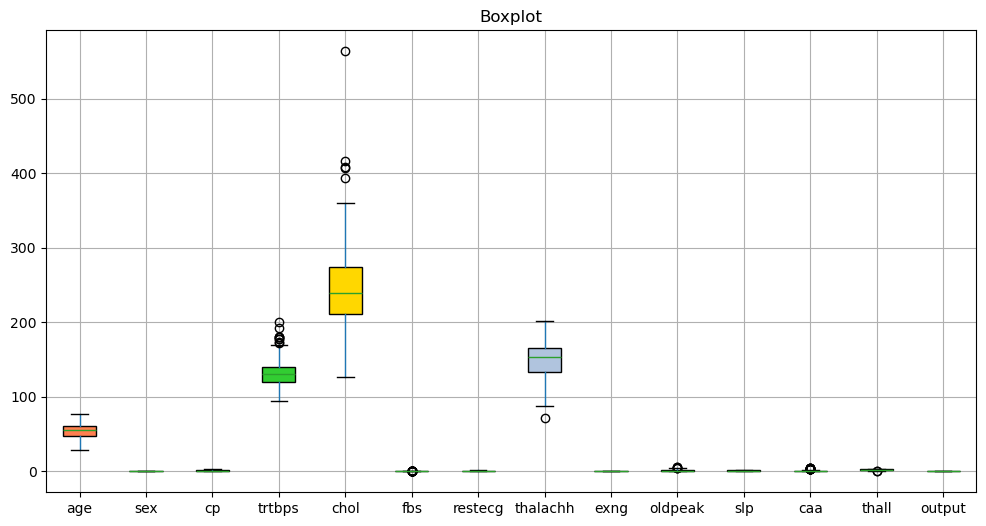

In [12]:
# Boxplot
colors = ['#FF7F50', '#87CEFA', '#DA70D6', '#32CD32', '#FFD700', '#6495ED', '#FF69B4', '#B0C4DE', '#FFA07A', '#20B2AA']

plt.figure(figsize=(12, 6))  
box = df.boxplot(patch_artist=True, boxprops=dict(facecolor=colors[0]), return_type='dict')

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)  

plt.title('Boxplot')
plt.show()

### <span style='color:purple'> Correlation</span>

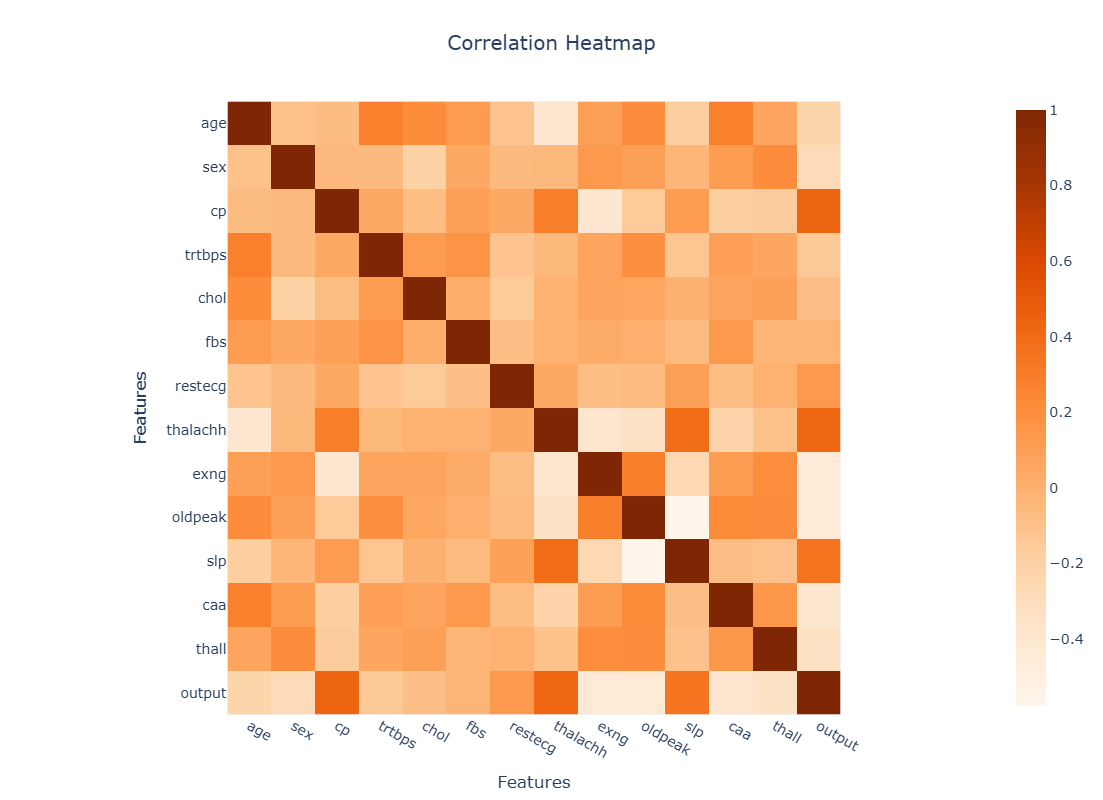

In [14]:
# Plotting Correlation Matrix
correlation_matrix = df.corr()

fig = px.imshow(
    correlation_matrix, x=correlation_matrix.columns,  y=correlation_matrix.columns,  
    title='Correlation Heatmap', color_continuous_scale='oranges')

fig.update_layout(
    title={'x': 0.5},
    width=900, height=800,
    xaxis_showgrid=False,  
    yaxis_showgrid=False,  
    xaxis_title='Features',  
    yaxis_title='Features',  
    title_text='Correlation Heatmap',  
    showlegend=False,  
    font_size=14)

fig.show()

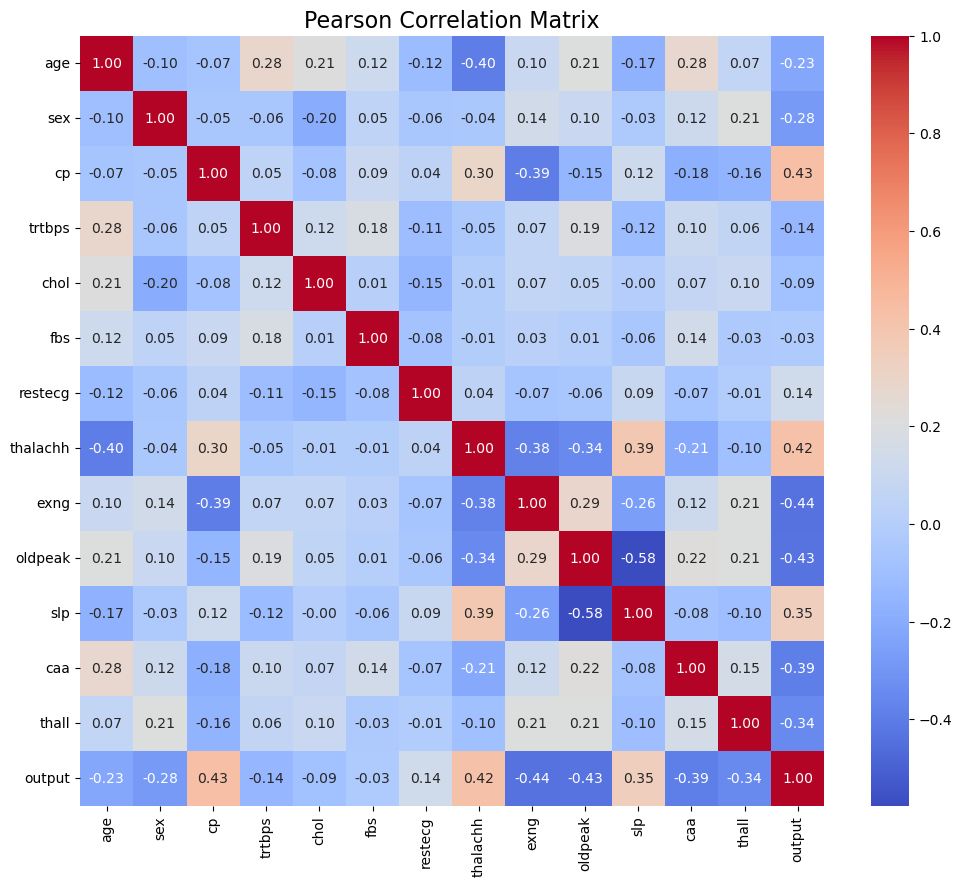

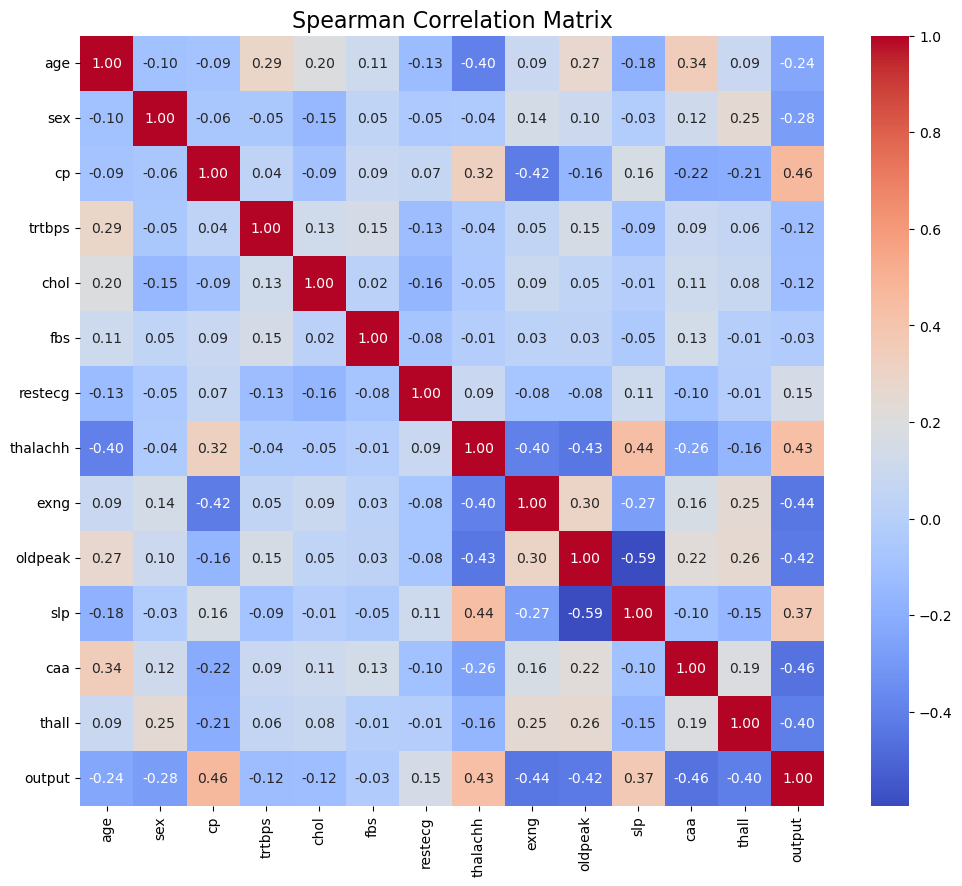

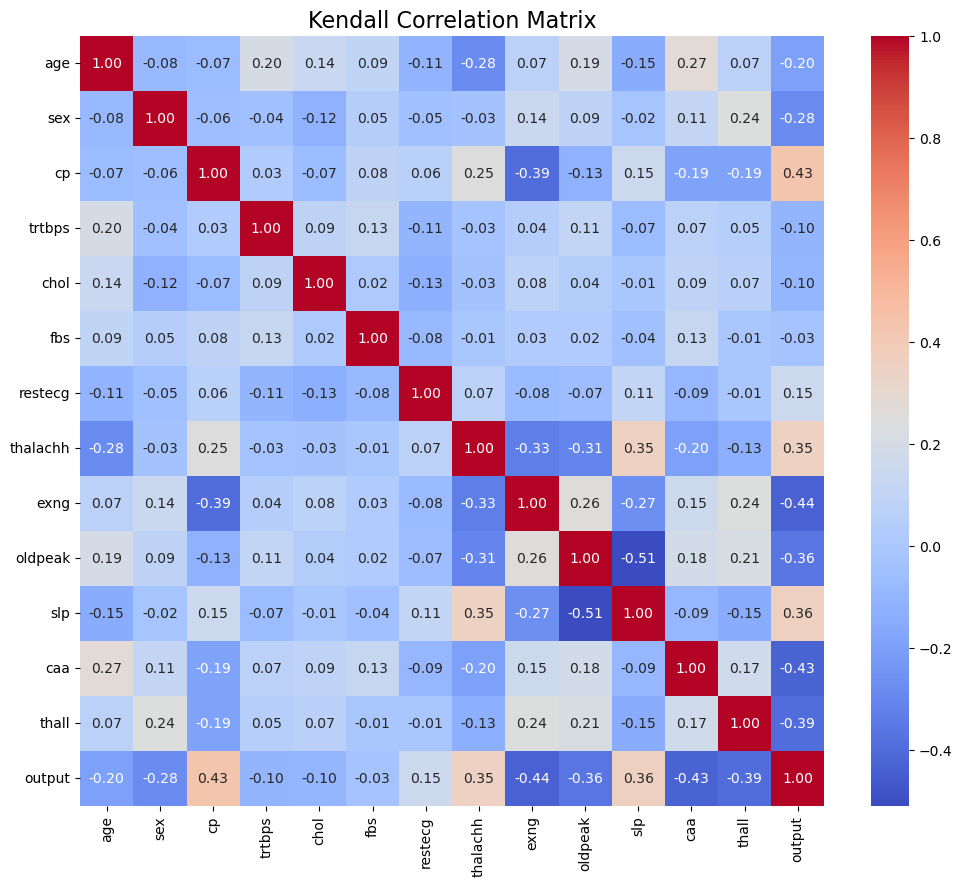

In [15]:
# Pearson correlation
plt.figure(figsize=(12, 10))  # Adjust figure size
pearson_corr = df.corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.show()

# Spearman correlation
plt.figure(figsize=(12, 10))  # Adjust figure size
spearman_corr = df.corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Spearman Correlation Matrix', fontsize=16)
plt.show()

# Kendall correlation
plt.figure(figsize=(12, 10))  # Adjust figure size
kendall_corr = df.corr(method='kendall')
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Kendall Correlation Matrix', fontsize=16)
plt.show()


## <span style='color:green'> Data Preprocessing</span>

In [17]:
    # Data Cleaning: No Null & only single duplicate data is present.
    # Droping duplicate data
    df.drop_duplicates(inplace=True)

In [18]:
# Data Splitting
X = df[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall']]
y = df['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Performing SMOTE for upsampling
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Displaying class distribution before and after SMOTE
print("Before SMOTE: ", Counter(y_train))
print("After SMOTE: ", Counter(y_train_resampled))

Before SMOTE:  Counter({1: 132, 0: 109})
After SMOTE:  Counter({1: 132, 0: 132})


In [19]:
# Feature Scaling
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

## <span style='color:green'> Model Training</span>

In [21]:
def Model_Training_And_Evaluation(Classifier):
    # Initialize the classifier and fit it to the training data
    model = Classifier
    model.fit(X_train_resampled, y_train_resampled)

    # Predict the test data
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probability estimates for ROC curve

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Calculate ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Create the first figure with performance indicators
    fig = make_subplots(rows=1, cols=4, specs=[[{"type": "domain"}, {"type": "domain"}, {"type": "domain"}, {"type": "domain"}]])

    # Accuracy gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=round(accuracy * 100, 2),
        title={'text': "Accuracy", 'font': {'size': 14}},
        gauge={'axis': {'range': [None, 100]},
              'bar': {'color': '#00CC96'}}
    ), row=1, col=1)

    # Precision gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=round(precision * 100, 2),
        title={'text': "Precision", 'font': {'size': 14}},
        gauge={'axis': {'range': [None, 100]},
              'bar': {'color': '#FF6692'}}
    ), row=1, col=2)

    # Recall gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=round(recall * 100, 2),
        title={'text': "Recall", 'font': {'size': 14}},
        gauge={'axis': {'range': [None, 100]},
              'bar': {'color': '#AB63FA'}}
    ), row=1, col=3)

    # F1 Score gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=round(f1 * 100, 2),
        title={'text': "F1 Score", 'font': {'size': 14}},
        gauge={'axis': {'range': [None, 100]},
              'bar': {'color': '#FFC107'}}
    ), row=1, col=4)

    # Updating the Layout
    fig.update_layout(
        title_text="Model Performance Metrics",
        title_x=0.5,
        height=250,
        width=1000,
        showlegend=False,
    )

    fig.show()

    # Plot the Confusion Matrix and ROC Curve
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))

    # Plot the Confusion Matrix on the first subplot
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axs[0], annot_kws={"size": 16})
    axs[0].set_title('Confusion Matrix', fontsize=18)
    axs[0].set_ylabel('Actual', fontsize=14)
    axs[0].set_xlabel('Predicted', fontsize=14)
    axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=12)
    axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=12)

    # Plot the ROC Curve on the second subplot
    axs[1].plot(fpr, tpr, color='orange', label=f'ROC curve (area = {roc_auc:.2f})')
    axs[1].plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    axs[1].set_xlim([0.0, 1.0])
    axs[1].set_ylim([0.0, 1.0])
    axs[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=18)
    axs[1].set_xlabel('False Positive Rate', fontsize=14)
    axs[1].set_ylabel('True Positive Rate', fontsize=14)
    axs[1].legend(loc='lower right', fontsize=12)

    # Adjust layout and display the plots
    plt.tight_layout()
    plt.show()


### <span style='color:purple'>1. Logistics Regression</span>

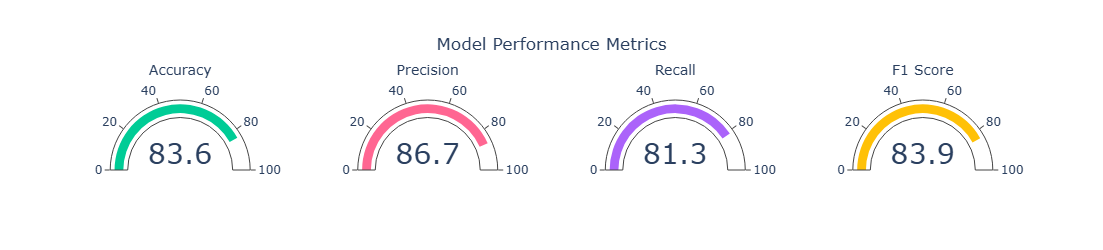

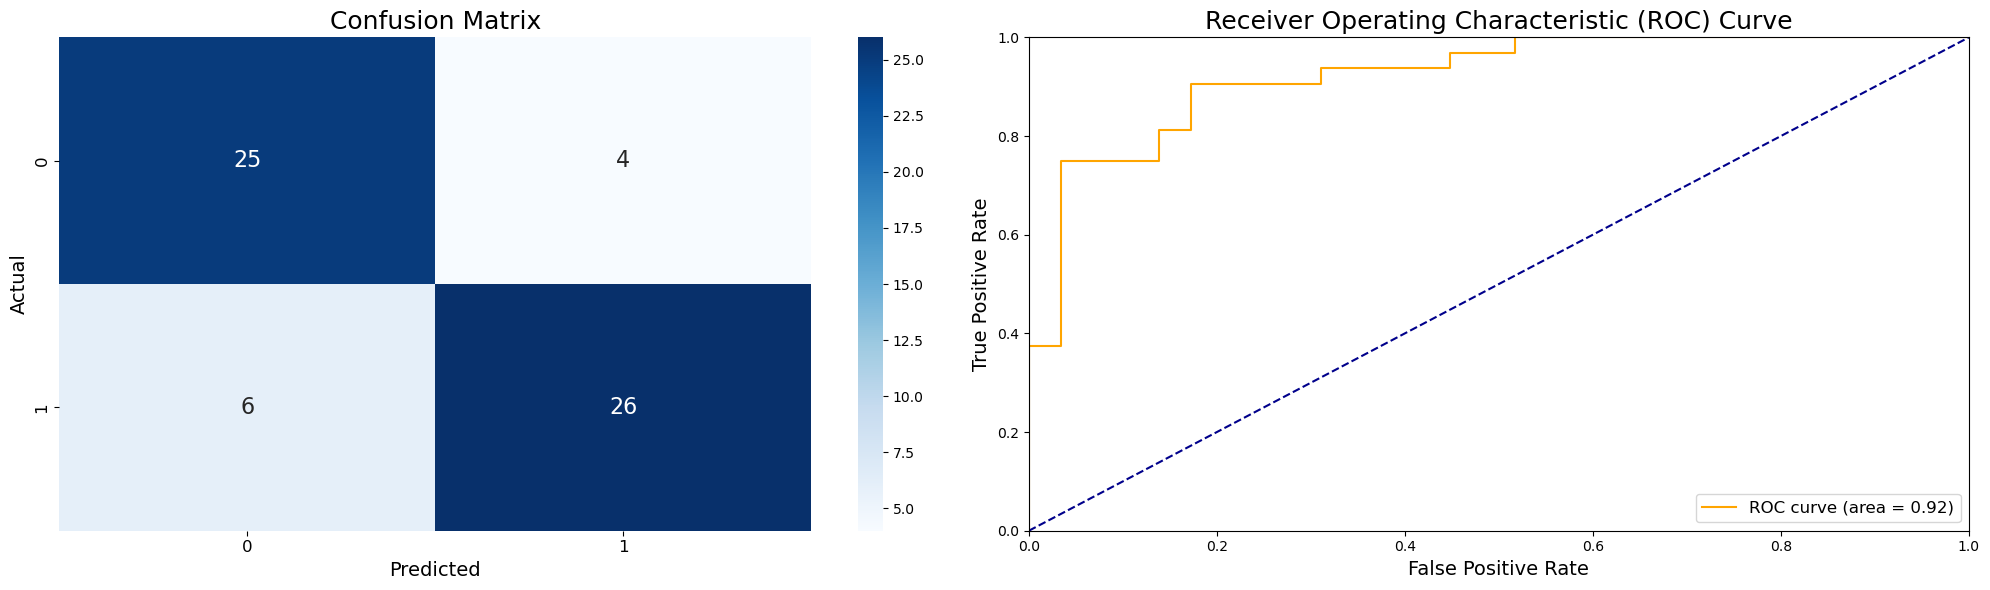

In [23]:
Model_Training_And_Evaluation(LogisticRegression())

### <span style='color:purple'>2. Support Vector Classifier</span>

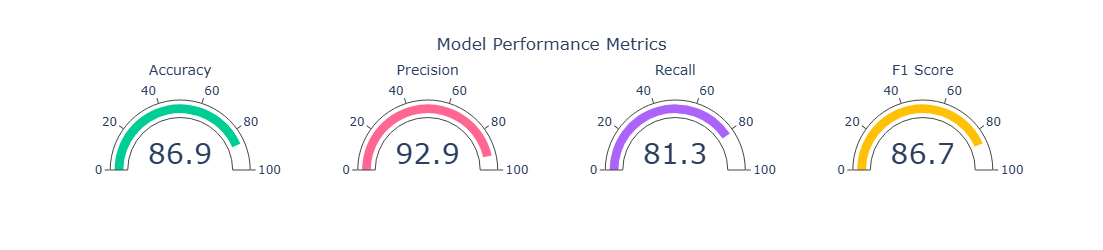

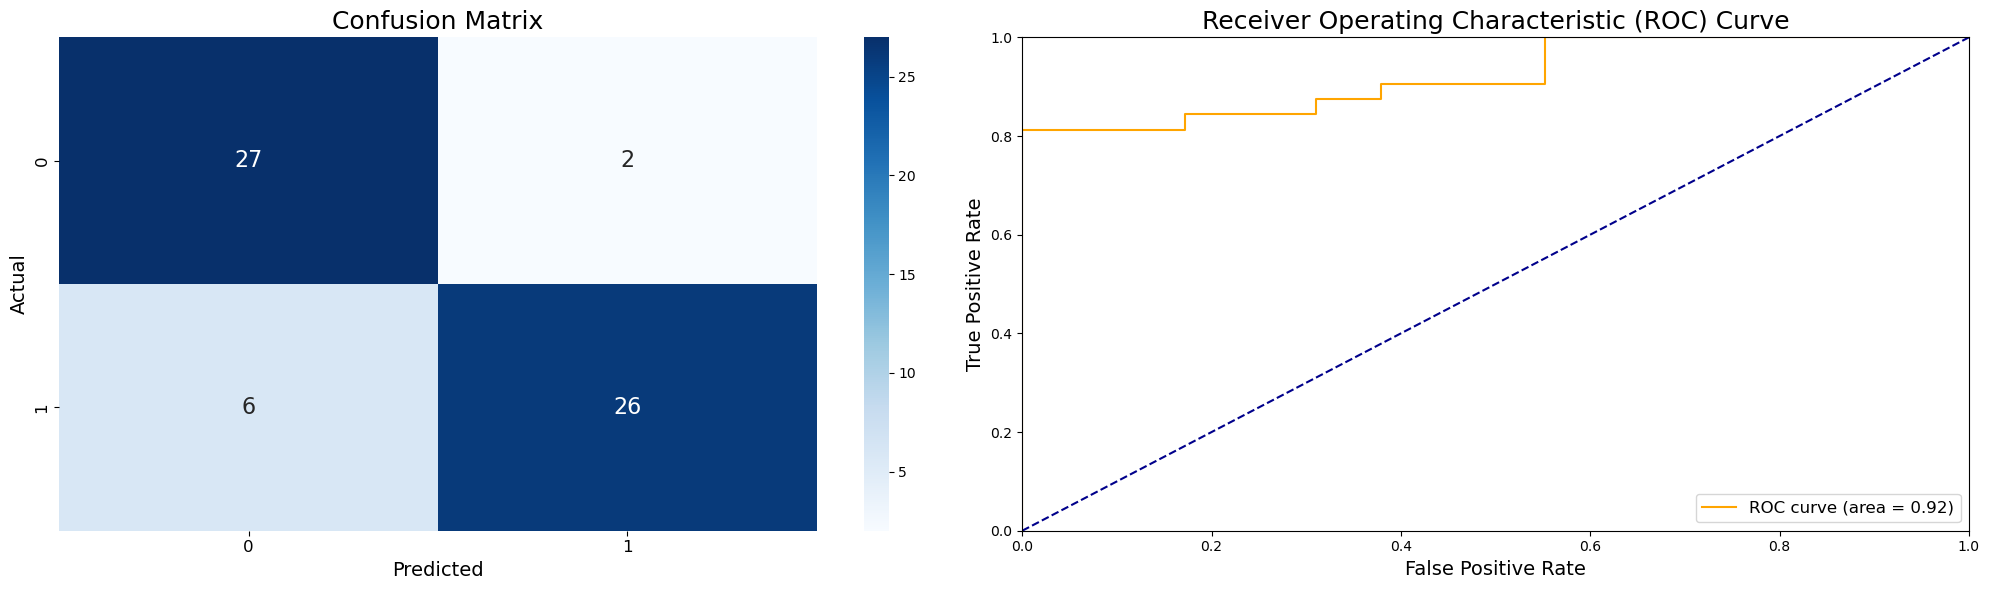

In [25]:
Model_Training_And_Evaluation(SVC(probability=True))

### <span style='color:purple'>3. K-Nearest Neighbor</span>

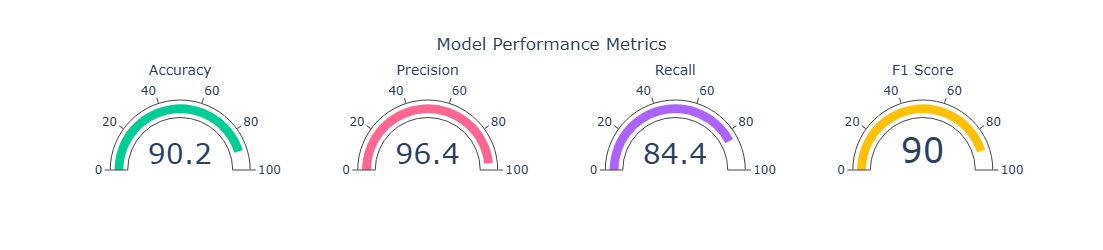

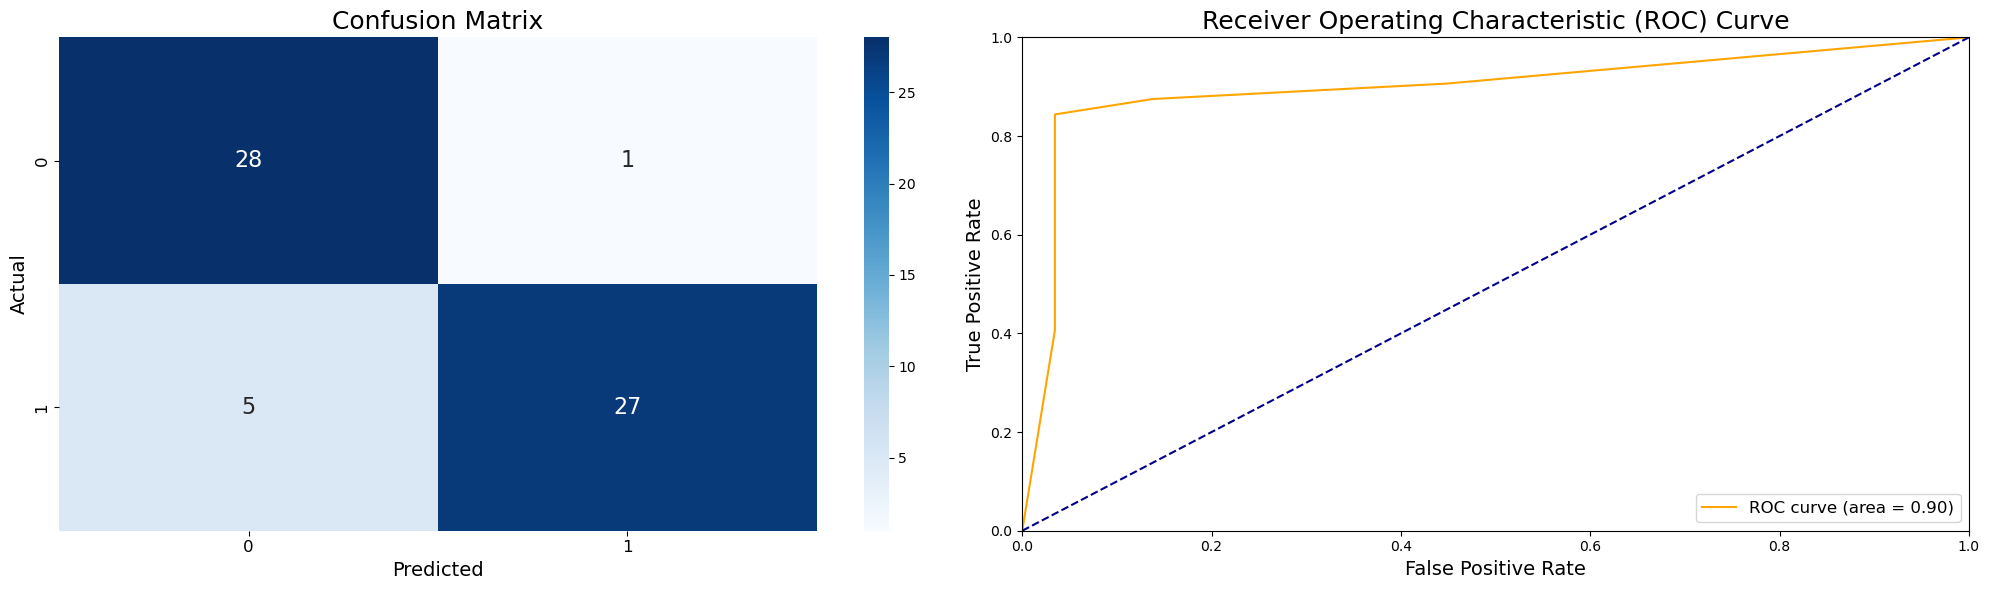

In [27]:
Model_Training_And_Evaluation(KNeighborsClassifier())

### <span style='color:purple'>4. Linear Discriminant Analysis</span>

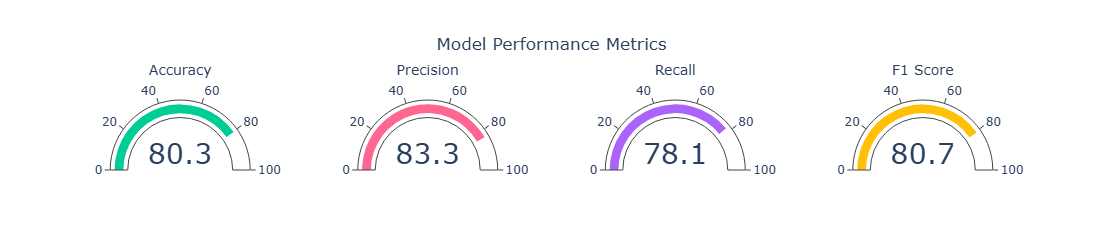

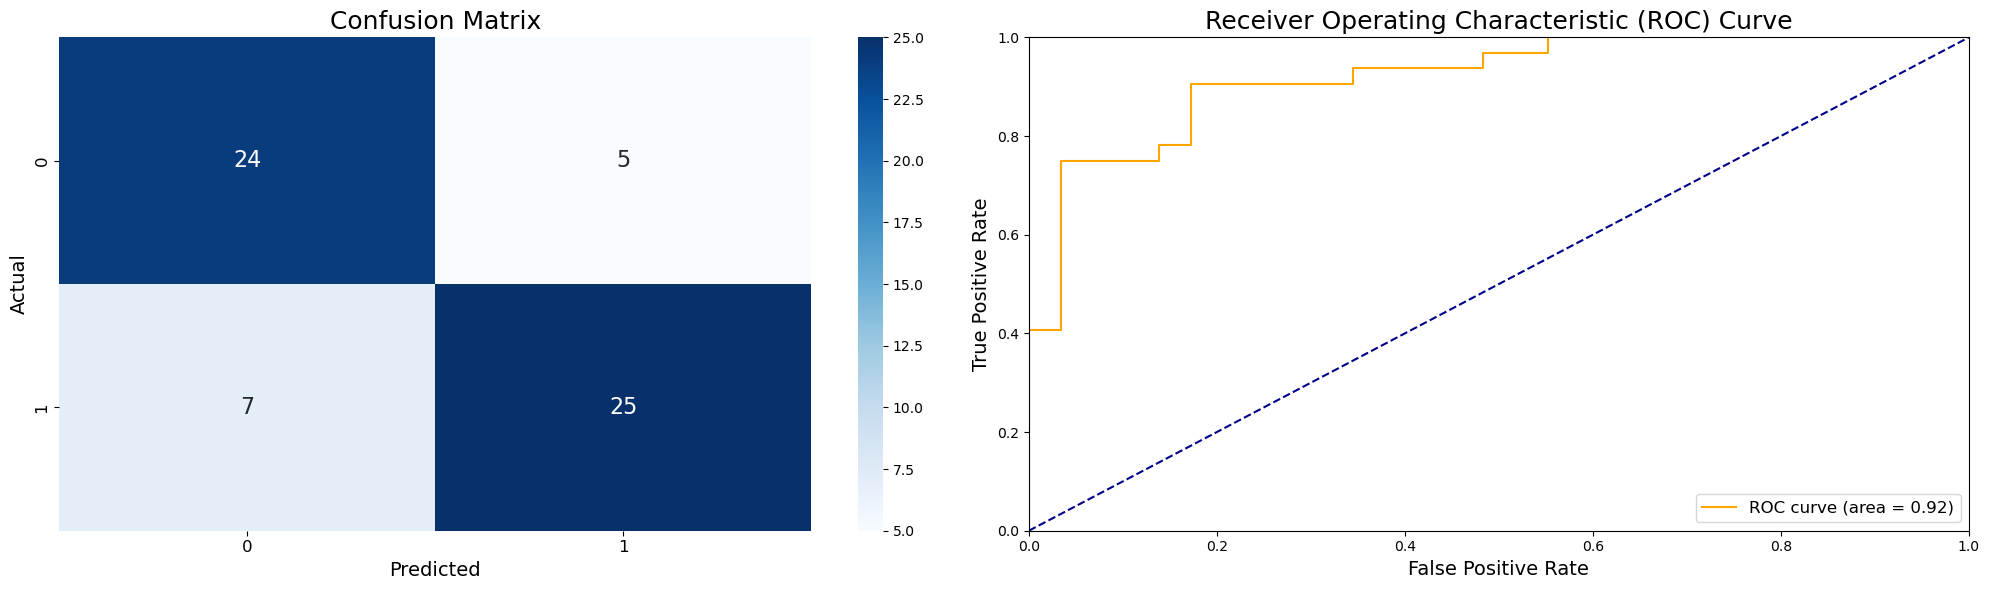

In [29]:
lda_model = LinearDiscriminantAnalysis()
Model_Training_And_Evaluation(lda_model)

### <span style='color:purple'>5.Quadratic Discriminant Analysis</span>

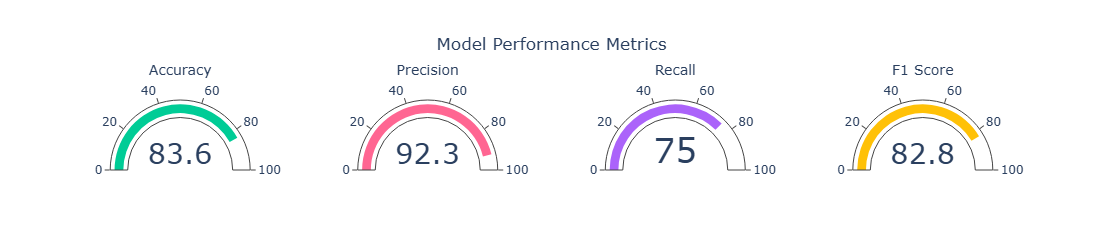

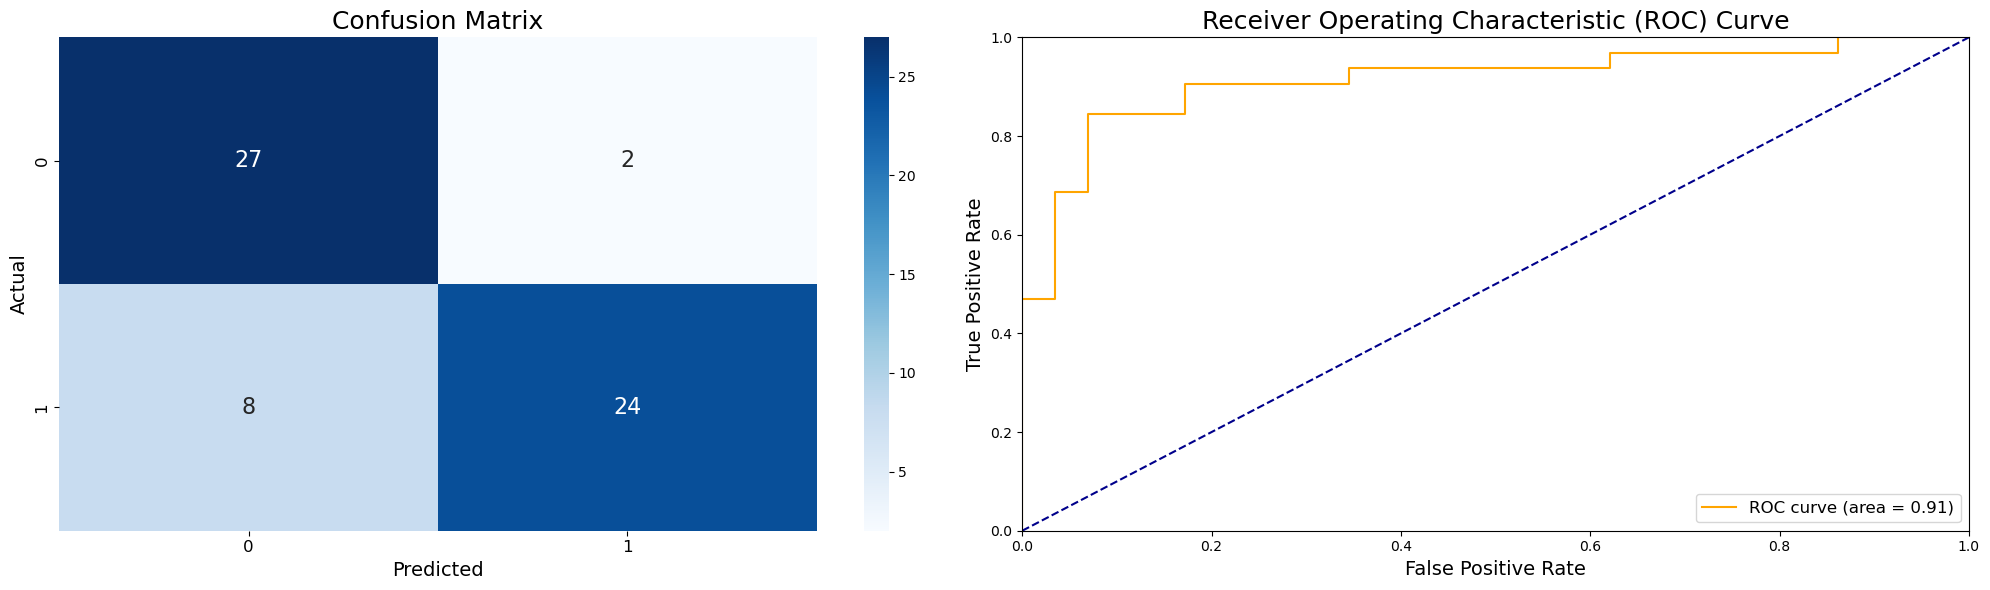

In [31]:
qda_model = QuadraticDiscriminantAnalysis()
Model_Training_And_Evaluation(qda_model)

### <span style='color:purple'>6. Naive Bayes Classifiers</span>

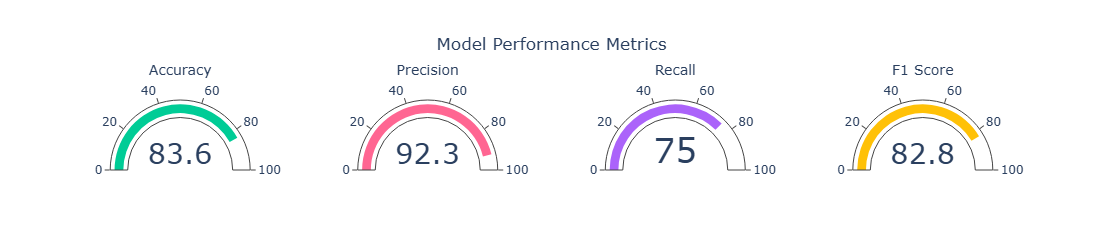

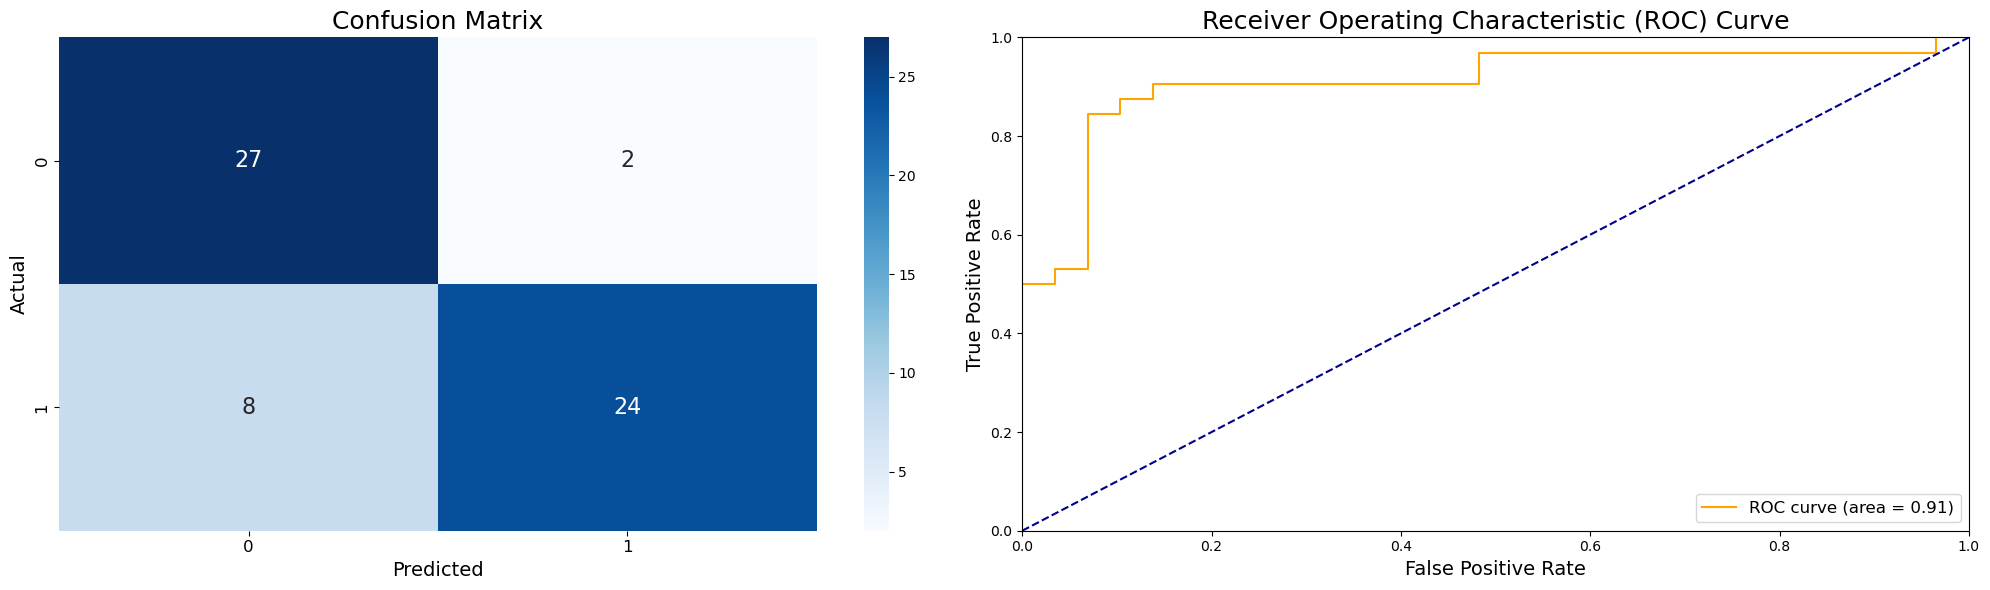

In [33]:
nb_model = GaussianNB()
Model_Training_And_Evaluation(nb_model)

### <span style='color:purple'>7. Random Forest</span>

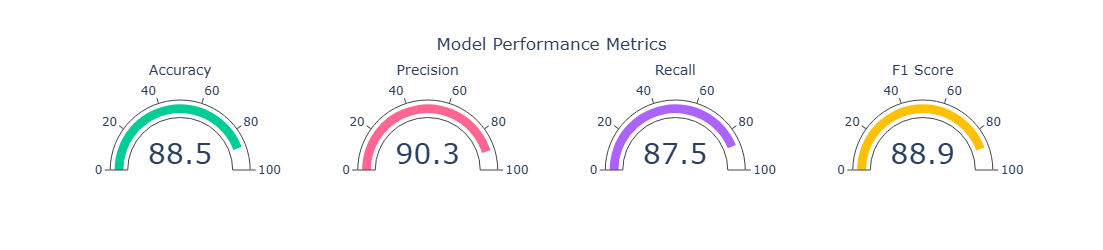

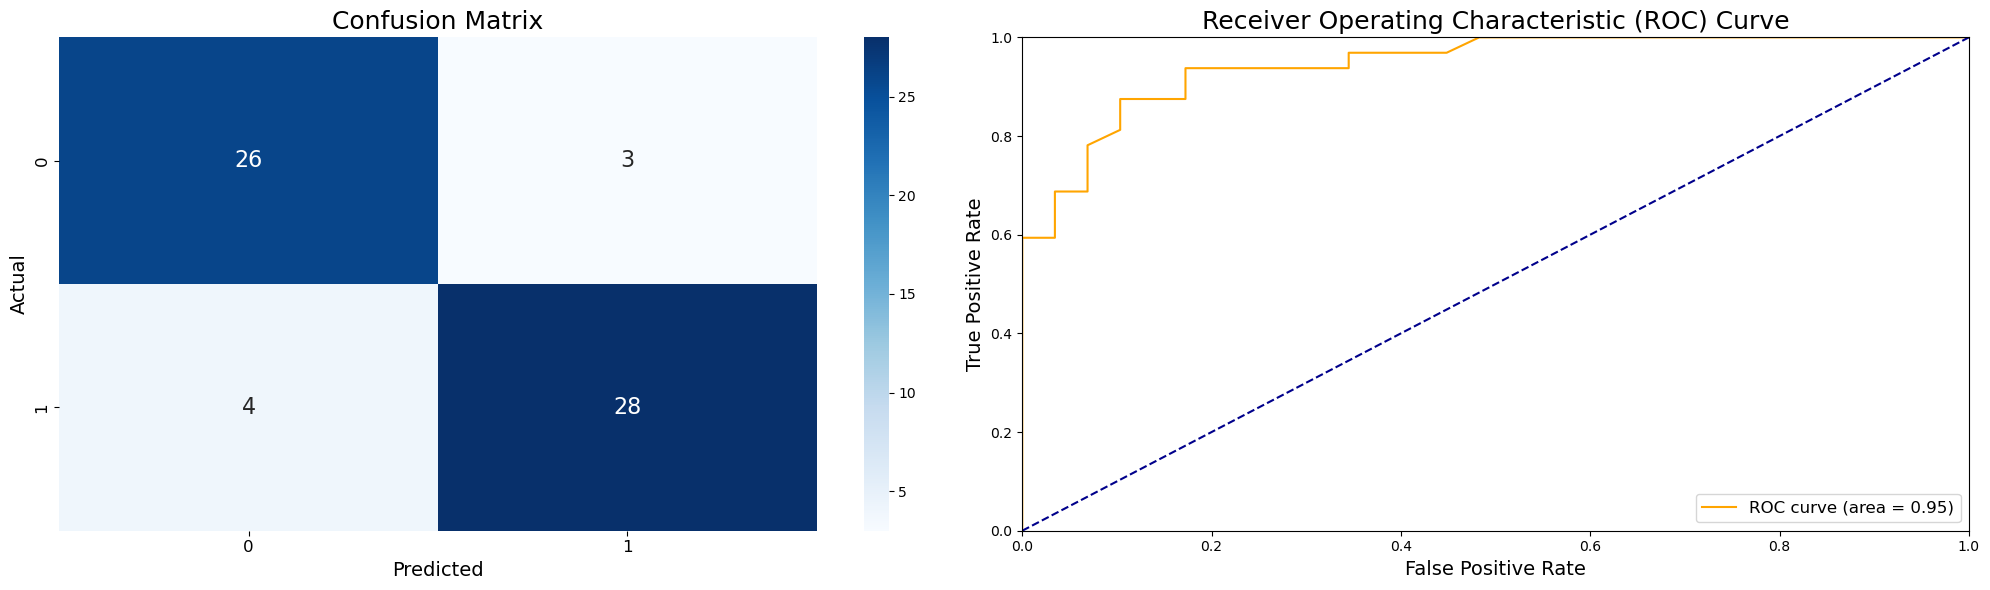

In [35]:
Model_Training_And_Evaluation(RandomForestClassifier())

### <span style='color:purple'>8. XGBoost</span>

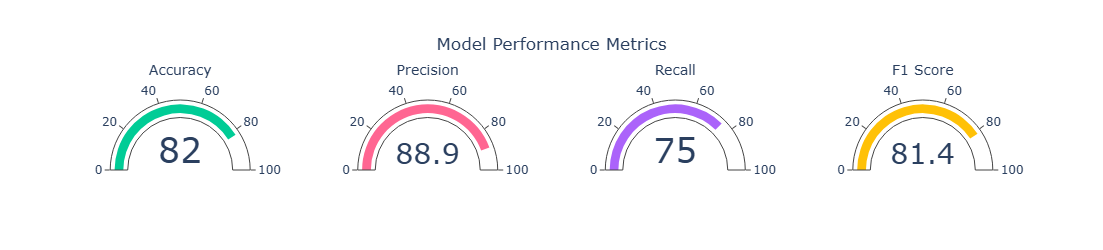

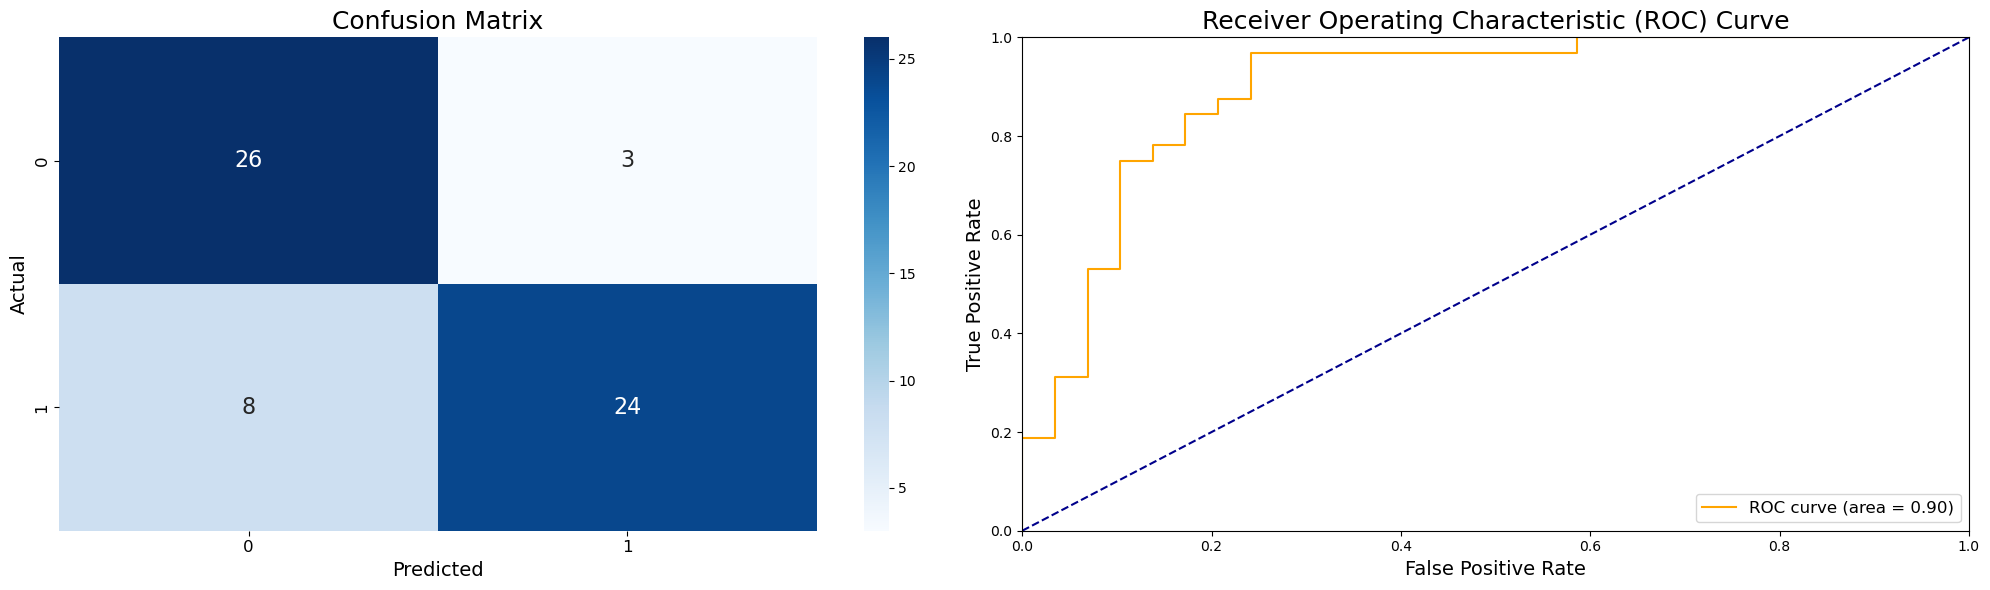

In [37]:
Model_Training_And_Evaluation(XGBClassifier())

### <span style='color:purple'>9. Neural Network MLPClassifier</span>

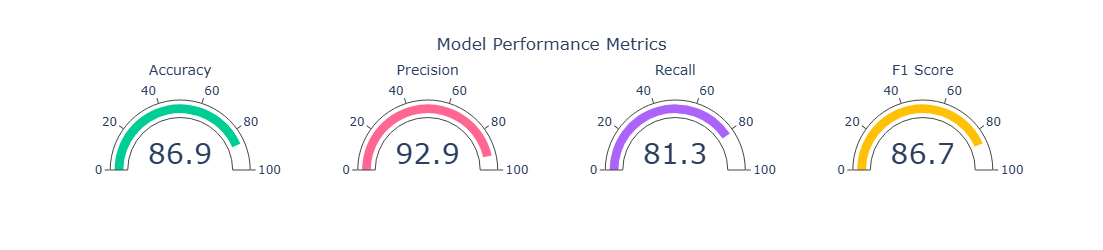

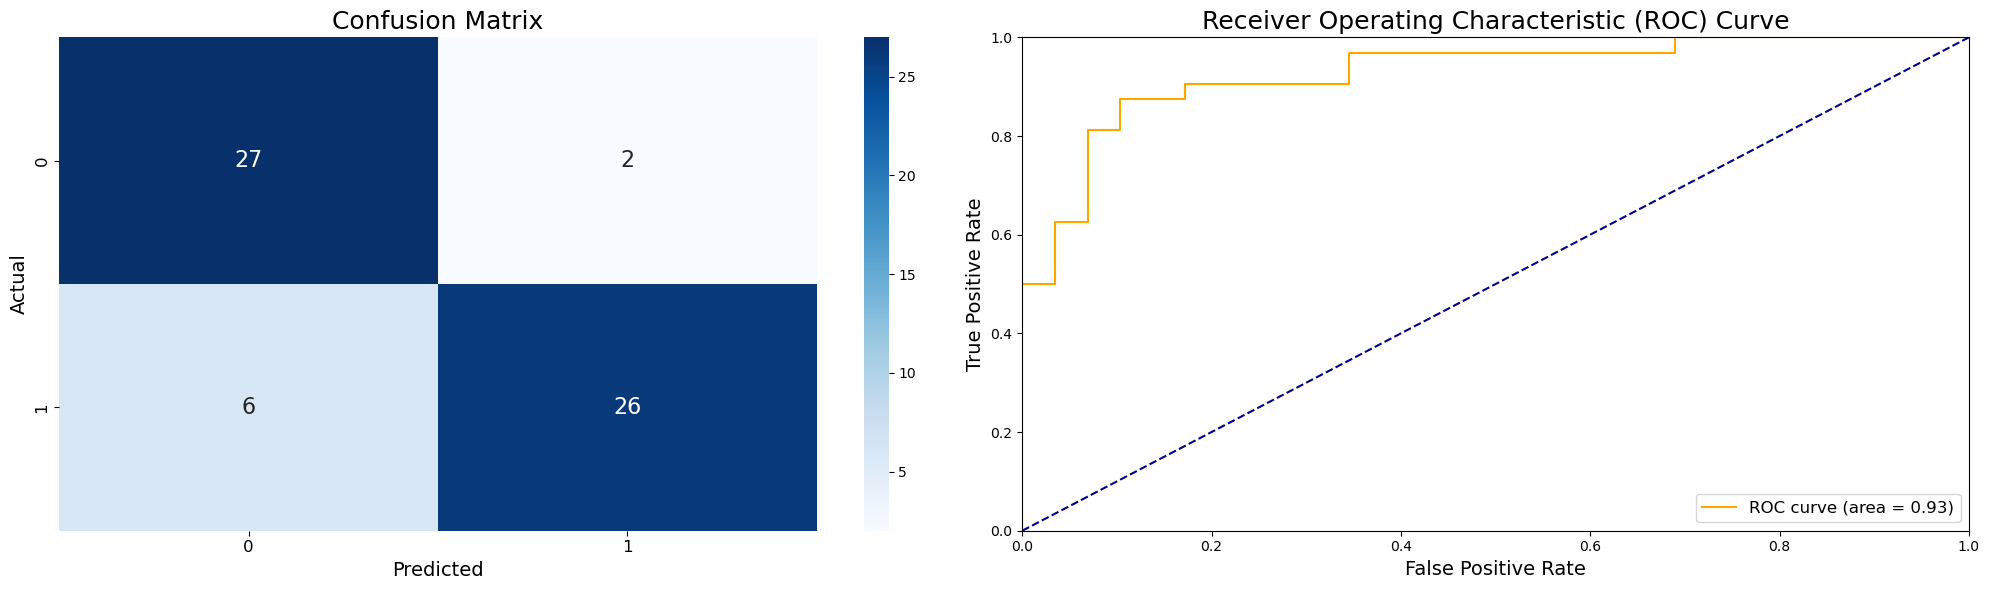

In [39]:
Model_Training_And_Evaluation(MLPClassifier())

## <span style='color:green'> Model Training Time</span>

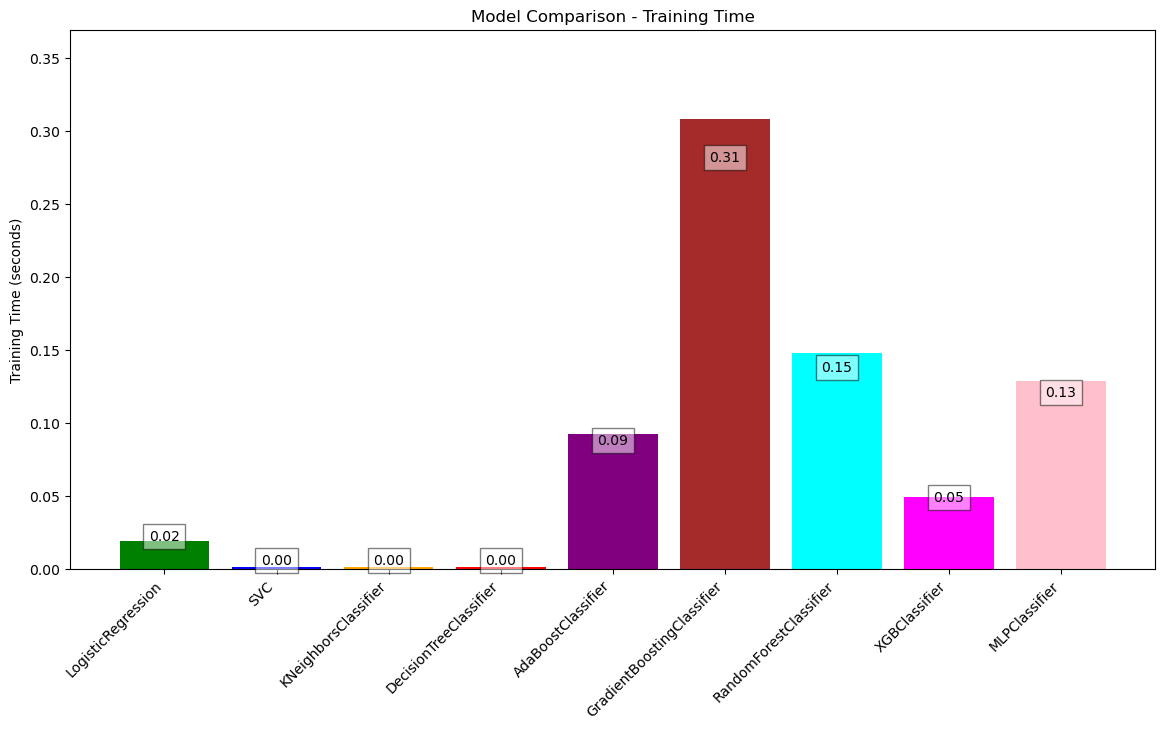

In [41]:
# Function to train model and return training time
def Model_Training_And_Evaluation(Classifier, X_train, y_train):
    model = Classifier

    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    return training_time

# Function to plot training times
def trainingTimeGraph(training_times, model_names):
    plt.figure(figsize=(14, 7))
    bars = plt.bar(model_names, training_times, color=['green', 'blue', 'orange', 'red', 'purple', 'brown', 'cyan', 'magenta', 'pink'])
    plt.ylabel('Training Time (seconds)')
    plt.title('Model Comparison - Training Time')
    plt.xticks(rotation=45, ha='right')
    
    # Get the maximum height of the bars for setting y-axis limit
    max_height = max(training_times)

    # Annotate each bar with its training time
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, 
            height - (height * 0.1),  # Position text within the bar
            f'{height:.2f}', 
            ha='center', 
            va='bottom',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')  # Add background to text
        )

    plt.ylim(0, max_height * 1.2)  # Increase the y-axis limit for better visualization
    plt.show()

# Load sample data
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models and record training times
training_time_lr = Model_Training_And_Evaluation(LogisticRegression(), X_train, y_train)
training_time_svc = Model_Training_And_Evaluation(SVC(), X_train, y_train)
training_time_knn = Model_Training_And_Evaluation(KNeighborsClassifier(), X_train, y_train)
training_time_dt = Model_Training_And_Evaluation(DecisionTreeClassifier(), X_train, y_train)
training_time_ab = Model_Training_And_Evaluation(AdaBoostClassifier(), X_train, y_train)
training_time_gb = Model_Training_And_Evaluation(GradientBoostingClassifier(), X_train, y_train)
training_time_rf = Model_Training_And_Evaluation(RandomForestClassifier(), X_train, y_train)
training_time_xgb = Model_Training_And_Evaluation(xgb.XGBClassifier(), X_train, y_train)
training_time_mlp = Model_Training_And_Evaluation(MLPClassifier(), X_train, y_train)

# Plot training times
trainingTimeGraph(
    [training_time_lr, training_time_svc, training_time_knn, training_time_dt, training_time_ab, training_time_gb, training_time_rf, training_time_xgb, training_time_mlp],
    ['LogisticRegression', 'SVC', 'KNeighborsClassifier', 'DecisionTreeClassifier', 'AdaBoostClassifier', 'GradientBoostingClassifier', 'RandomForestClassifier', 'XGBClassifier', 'MLPClassifier']
)

## <span style='color:green'> Learning Curve</span>

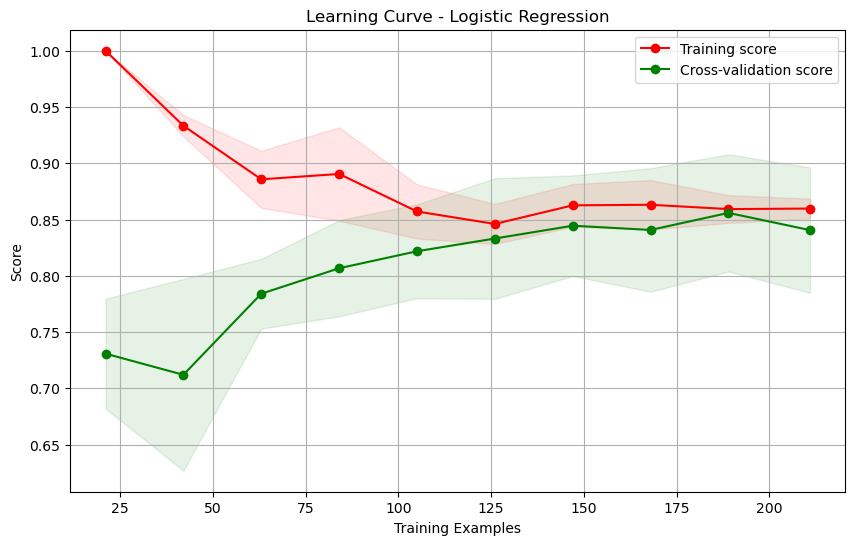

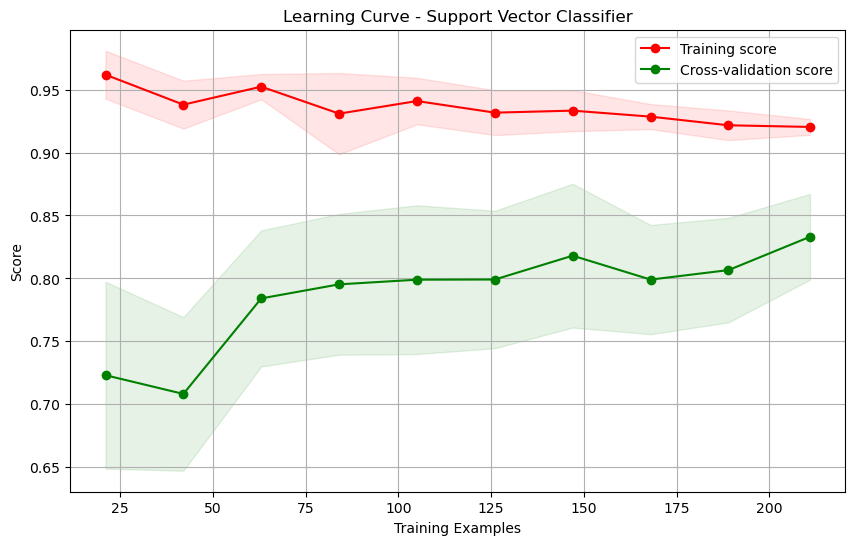

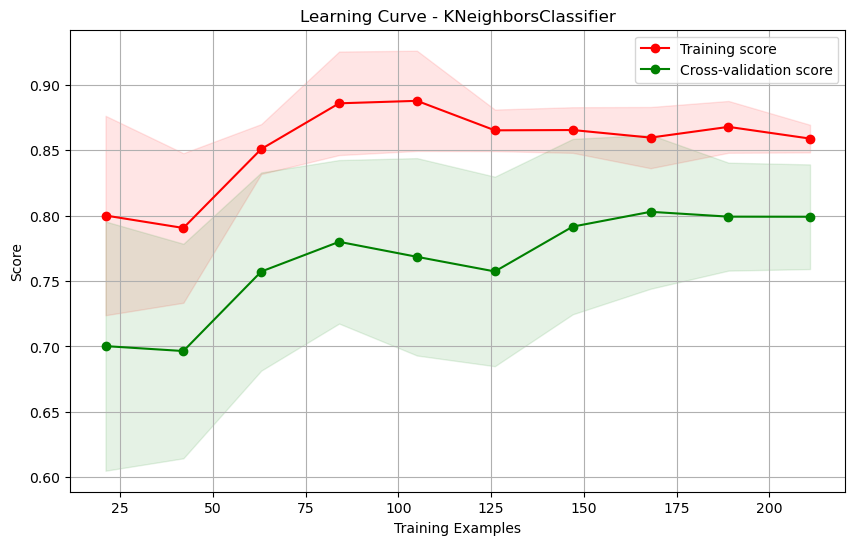

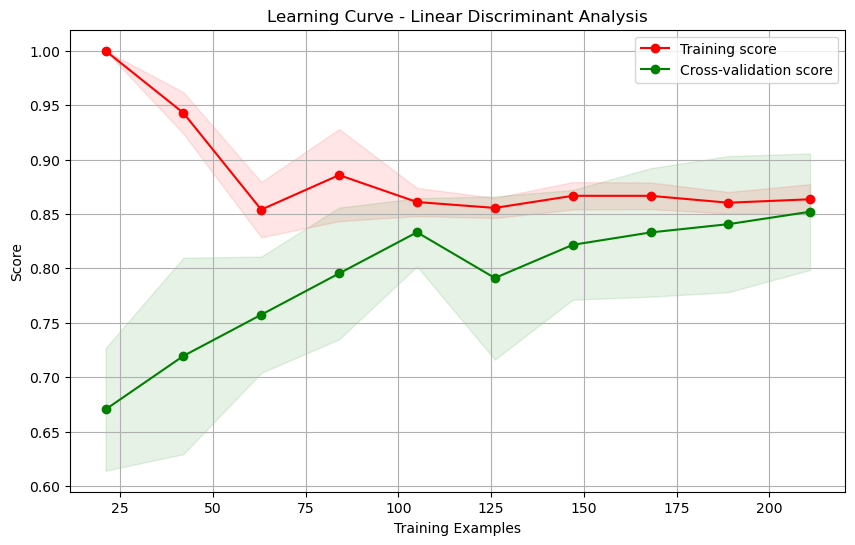

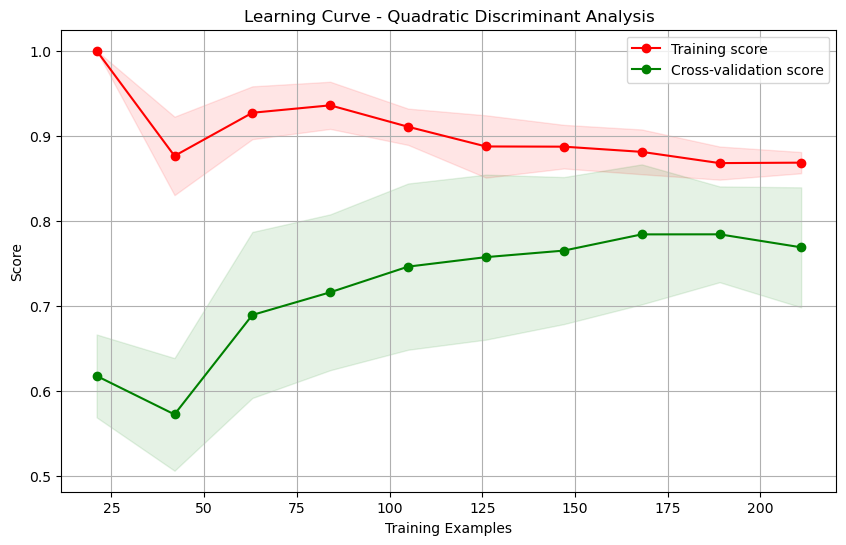

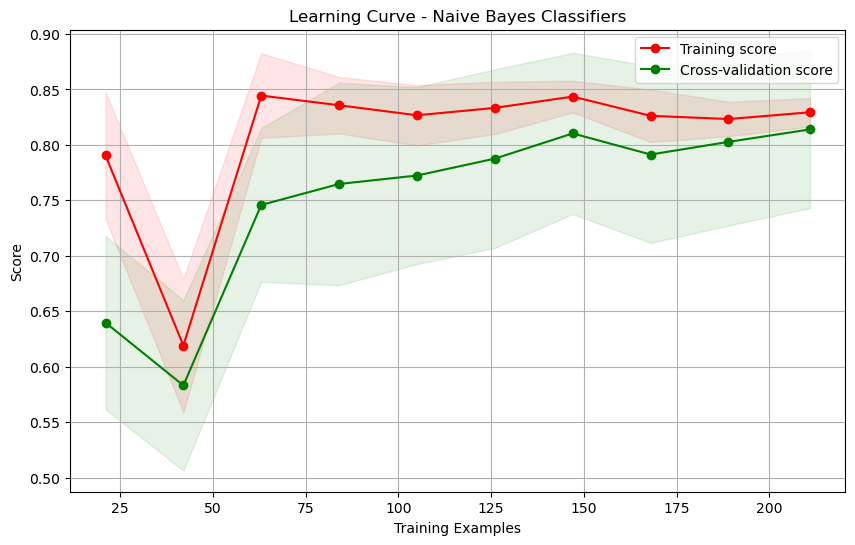

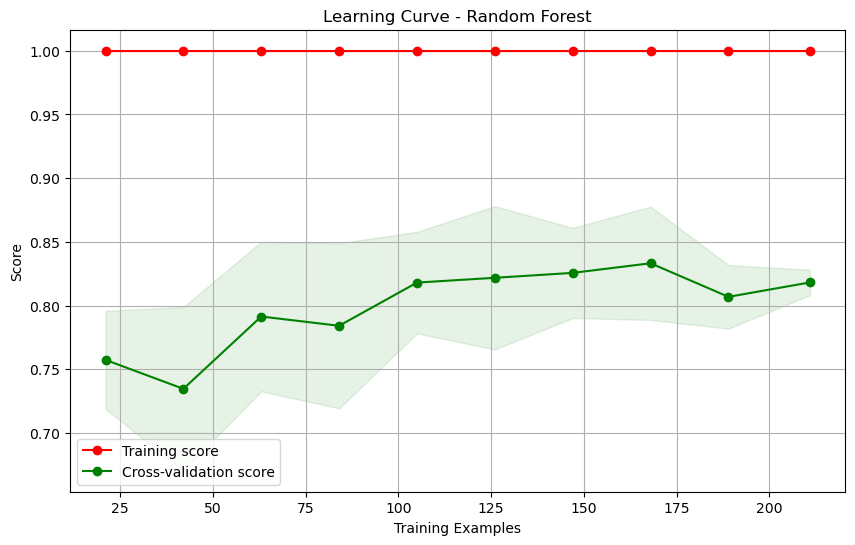

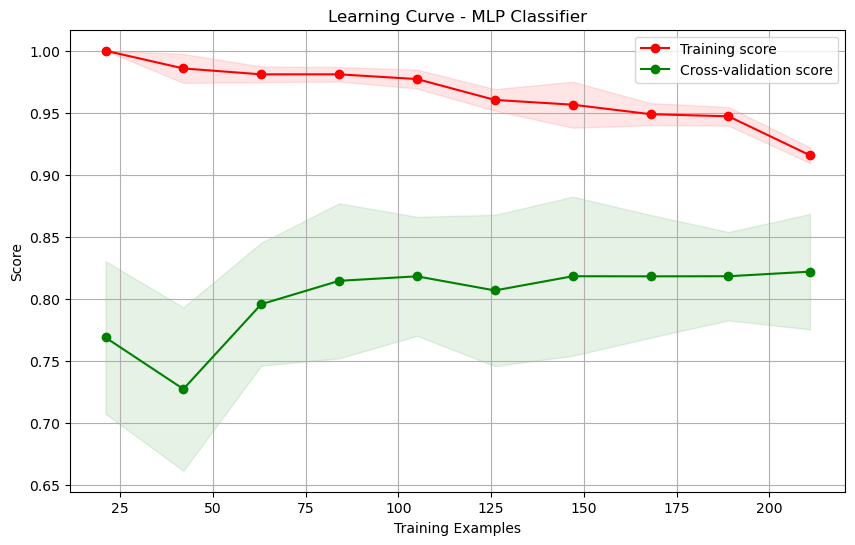

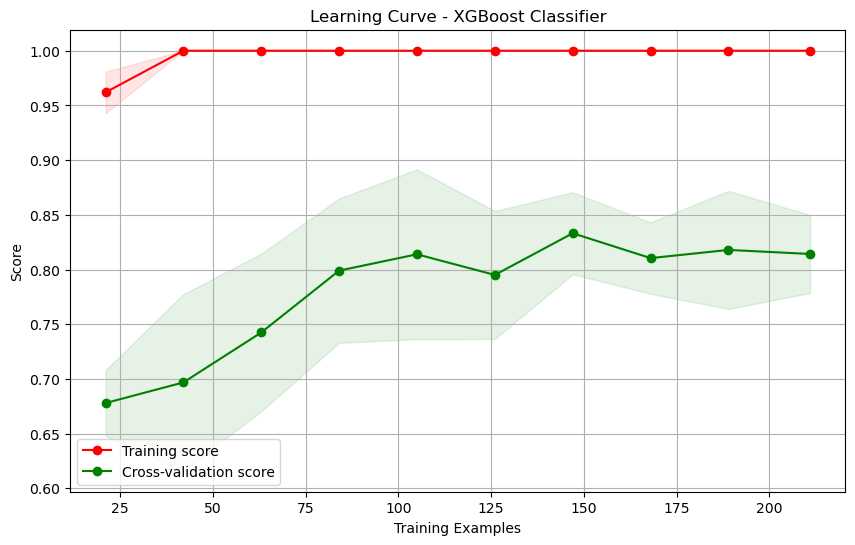

In [43]:
# Function to plot learning curve for a given model
def plot_learning_curve(model, X, y, title="Learning Curve", cv=5, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(10, 6))
    
    # Generate learning curve data
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    # Calculate mean and standard deviation for training and test scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.title(f"{title}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Applying the function to plot learning curves for different models

# 1. Logistic Regression
plot_learning_curve(LogisticRegression(), X_train_resampled, y_train_resampled, title="Learning Curve - Logistic Regression")

# 2. SVC
plot_learning_curve(SVC(), X_train_resampled, y_train_resampled, title="Learning Curve - Support Vector Classifier")

# 3. KNeighborsClassifier
plot_learning_curve(KNeighborsClassifier(), X_train_resampled, y_train_resampled, title="Learning Curve - KNeighborsClassifier")

# 4. Linear Discriminant Analysis
plot_learning_curve(LinearDiscriminantAnalysis(), X_train_resampled, y_train_resampled, title="Learning Curve - Linear Discriminant Analysis")

# 5. Quadratic Discriminant Analysis
plot_learning_curve(QuadraticDiscriminantAnalysis(), X_train_resampled, y_train_resampled, title="Learning Curve - Quadratic Discriminant Analysis")

# 6. Naive Bayes Classifiers
plot_learning_curve(GaussianNB(), X_train_resampled, y_train_resampled, title="Learning Curve - Naive Bayes Classifiers")

# 7. Random Forest
plot_learning_curve(RandomForestClassifier(), X_train_resampled, y_train_resampled, title="Learning Curve - Random Forest")

# 9. MLP Classifier
plot_learning_curve(MLPClassifier(), X_train_resampled, y_train_resampled, title="Learning Curve - MLP Classifier")

# 8. XGBoost Classifier
plot_learning_curve(XGBClassifier(), X_train_resampled, y_train_resampled, title="Learning Curve - XGBoost Classifier")